In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import re

# **Load Raw CSV Files**

In [2]:
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/#UIU-My WORK/2nd sems/Data Analytics/Excel Synthetic Data"

customers_raw = pd.read_csv(f"{BASE_PATH}/customers_raw_messy.csv")
books_raw = pd.read_csv(f"{BASE_PATH}/books_raw_messy.csv")
stores_raw = pd.read_csv(f"{BASE_PATH}/stores_raw_messy.csv")
suppliers_raw = pd.read_csv(f"{BASE_PATH}/suppliers_raw_messy.csv")
sales_raw = pd.read_csv(f"{BASE_PATH}/sales_raw_messy.csv")

print("Files loaded successfully")

Files loaded successfully


# **Dataset Overview**

In [3]:
tables = {
    "Customers": customers_raw,
    "Books": books_raw,
    "Stores": stores_raw,
    "Suppliers": suppliers_raw,
    "Sales": sales_raw
}

for name, df in tables.items():

    print("\n" + "="*80)
    print(name)
    print("="*80)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nSample:")
    display(df.head())


Customers
Shape: (1000, 12)

Columns:
['customer_id', 'customer_name', 'gender', 'age', 'city', 'region', 'signup_date', 'customer_segment', 'email', 'phone', 'loyalty_score', 'reader_group']

Data Types:
customer_id          object
customer_name        object
gender               object
age                 float64
city                 object
region               object
signup_date          object
customer_segment     object
email                object
phone                object
loyalty_score       float64
reader_group         object
dtype: object

Sample:


,customer_id,customer_name,gender,age,city,region,signup_date,customer_segment,email,phone,loyalty_score,reader_group
0,C00001,Sifat Sarker,Male,21.0,Brahmanbaria,Chattogram,10/8/2022 18:26,Bronze,NaN,01573681081,34.0,Young
1,C00002,Sami Sheikh,Male,24.0,DHAKA,Dhaka,10/25/2024 10:49,Gold,sami.uddin@yahoo.com,01391624938,63.0,Young
2,C00003,Nafis Khan,Male,21.0,NaN,Dhaka,12/20/2023 7:28,Gold,nusrat.das@outlook.com,01959490272,77.0,Young
3,C00004,Shuvo Uddin,Male,150.0,Rangamati,Chattogram,7/17/2021 6:43,Gold,rafi.sheikh@outlook.com,01423607802,80.0,Professional
4,C00005,Nusrat Miah,Female,19.0,Munshiganj,Dhaka,3/1/2022 20:23,Silver,hasan.miah@outlook.com,01781413381,55.0,Young



Books
Shape: (1000, 16)

Columns:
['product_id', 'product_name', 'category', 'sub_category', 'author_name', 'publisher_name', 'unit_price', 'cost_price', 'supplier_id', 'stock_quantity', 'launch_date', 'format', 'language', 'page_count', 'reader_group', 'best_seller_score']

Data Types:
product_id            object
product_name          object
category              object
sub_category          object
author_name           object
publisher_name        object
unit_price           float64
cost_price           float64
supplier_id           object
stock_quantity       float64
launch_date           object
format                object
language              object
page_count             int64
reader_group          object
best_seller_score    float64
dtype: object

Sample:


,product_id,product_name,category,sub_category,author_name,publisher_name,unit_price,cost_price,supplier_id,stock_quantity,launch_date,format,language,page_count,reader_group,best_seller_score
0,P00001,Short Stories Masterclass,Fiction,Short Stories,Amin Ahmed,Green Books Ltd,454.53,NaN,S00483,453.0,10/18/2022 21:54,Hardcover,Bangla,277,Professional,0.984
1,P00002,Entrepreneurship Handbook,Business,Entrepreneurship,Naila Uddin,Prime Supply Co,518.21,334.91,S00143,244.0,4/4/2021 15:28,Paperback,Bangla,841,Kids,0.455
2,P00003,Databases Handbook Series,Programming,Databases,Jalal Islam,Bright Supply Co,1001.02,625.99,S00970,553.0,9/6/2020 21:29,eBook,English,842,Elderly,0.314
3,P00004,English Grammar Masterclass Series,Academic,English Grammar,Mala Chowdhury,Eastern Trade Group,537.49,403.33,S00982,238.0,12/25/2021 3:47,eBook,English,674,Young,0.991
4,P00005,Bank Jobs Guide Practice,Exam Prep,Bank Jobs,Mohiuddin Rahman,Delta Supply Co,930.27,715.75,S00214,482.0,8/4/2021 5:55,eBook,English,675,Kids,0.503



Stores
Shape: (1000, 11)

Columns:
['store_id', 'store_name', 'city', 'region', 'store_type', 'opening_date', 'manager_name', 'floor_area', 'monthly_rent', 'employee_count', 'store_rating']

Data Types:
store_id           object
store_name         object
city               object
region             object
store_type         object
opening_date       object
manager_name       object
floor_area        float64
monthly_rent      float64
employee_count    float64
store_rating      float64
dtype: object

Sample:


,store_id,store_name,city,region,store_type,opening_date,manager_name,floor_area,monthly_rent,employee_count,store_rating
0,ST00001,Readers Point Branch - Manikganj,Madaripur,Dhaka,Flagship,12/19/2025 23:07,Shaila Ahmed,2677.74,64043.41,20.0,4.92
1,ST00002,Rokomari Branch - Rajbari,Tangail,Dhaka,Mini,8/1/2017 0:53,Mahin Nahar,1206.76,86635.24,38.0,4.52
2,ST00003,BookHub Branch - Chittagong,Munshiganj,Dhaka,Standard,7/19/2021 12:44,Tanjim Bhuiyan,3820.77,224329.55,9.0,3.57
3,ST00004,Rokomari Branch - Brahmanbaria,DHAKA,Dhaka,Standard,12/11/2017 5:09,Raisa Uddin,3326.62,110611.43,47.0,3.39
4,ST00005,Novel Nest Center - Dhaka,Gazipur,Dhaka,Mini,6/8/2021 10:49,Sifat Amin,5898.30,85921.55,4.0,4.10



Suppliers
Shape: (1000, 13)

Columns:
['supplier_id', 'supplier_name', 'country', 'contact_person', 'phone', 'email', 'product_category', 'rating', 'contract_start_date', 'delivery_time_days', 'city', 'status', 'region']

Data Types:
supplier_id             object
supplier_name           object
country                 object
contact_person          object
phone                  float64
email                   object
product_category        object
rating                 float64
contract_start_date     object
delivery_time_days       int64
city                    object
status                  object
region                  object
dtype: object

Sample:


,supplier_id,supplier_name,country,contact_person,phone,email,product_category,rating,contract_start_date,delivery_time_days,city,status,region
0,S00001,Global Supply Co,Bangladesh,Tanjim Patwary,1.767618e+09,nabil.das@gmail.com,Academic,4.61,2020-05-20 11:49:34,8,Gopalganj,Active,Dhaka
1,S00002,Bright Enterprises,Bangladesh,Karim Das,1.735269e+09,hasan.roy@outlook.com,Fiction,4.59,2024-10-19 08:28:38,9,Cumilla,Active,Chattogram
2,S00003,Delta Trade Group,Bangladesh,Shuvo Karim,1.816283e+09,tanjim.sarker@gmail.com,Biography,3.57,2023-01-01 18:46:34,6,Noakhali,Active,Chattogram
3,S00004,Global Logistics,Bangladesh,Muntasir Jahan,1.345700e+09,tasnima.jahan@outlook.com,Programming,4.92,2024-12-16 07:17:16,9,Gopalganj,Active,Dhaka
4,S00005,Prime Books Ltd,Bangladesh,Tanvir Khan,1.869133e+09,NaN,Biography,4.95,2019-06-09 05:50:23,17,Cumilla,Active,Chattogram



Sales
Shape: (2000, 14)

Columns:
['sales_id', 'supplier_id', 'customer_id', 'product_id', 'store_id', 'sales_date', 'quantity', 'unit_price', 'discount', 'total_amount', 'payment_method', 'sales_channel', 'reader_group', 'category']

Data Types:
sales_id           object
supplier_id        object
customer_id        object
product_id         object
store_id           object
sales_date         object
quantity          float64
unit_price        float64
discount          float64
total_amount      float64
payment_method     object
sales_channel      object
reader_group       object
category           object
dtype: object

Sample:


,sales_id,supplier_id,customer_id,product_id,store_id,sales_date,quantity,unit_price,discount,total_amount,payment_method,sales_channel,reader_group,category
0,SLS000001,S00556,C00980,P00204,ST00388,5/30/2025,3.0,297.77,0.14,768.25,Nagad,Online,Young,Biography
1,SLS000002,S00179,C00104,P00109,ST00166,5/5/2025,1.0,397.12,0.11,353.44,Card,NaN,Young,Programming
2,SLS000003,S00608,C00073,P00238,ST00634,8/27/2024,1.0,659.86,0.08,607.07,Nagad,Online,Professional,Fiction
3,SLS000004,S00989,C00530,P00503,ST00285,2/10/2025,3.0,399.02,0.12,1053.41,Nagad,ONLINE,Young,Business
4,SLS000005,S00794,C00612,P00243,ST00634,5/14/2025,3.0,1098.68,0.16,2768.67,Card,Online,Young,Academic


# **Missing Value Audit**

In [4]:
import pandas as pd
import numpy as np

missing_report = []

for name, df in tables.items():

    temp = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_percent": (df.isnull().mean().values * 100).round(2)
    })

    temp["table"] = name

    missing_report.append(temp)

missing_report = pd.concat(missing_report)

missing_report.sort_values(
    "missing_percent",
    ascending=False,
    inplace=True
)

display(missing_report)

,column,missing_count,missing_percent,table
9,phone,40,4.0,Customers
3,age,40,4.0,Customers
6,quantity,80,4.0,Sales
8,discount,80,4.0,Sales
8,email,40,4.0,Customers
...,...,...,...,...
2,customer_id,0,0.0,Sales
9,total_amount,0,0.0,Sales
7,unit_price,0,0.0,Sales
12,reader_group,0,0.0,Sales


# **Visualize Missing Values**

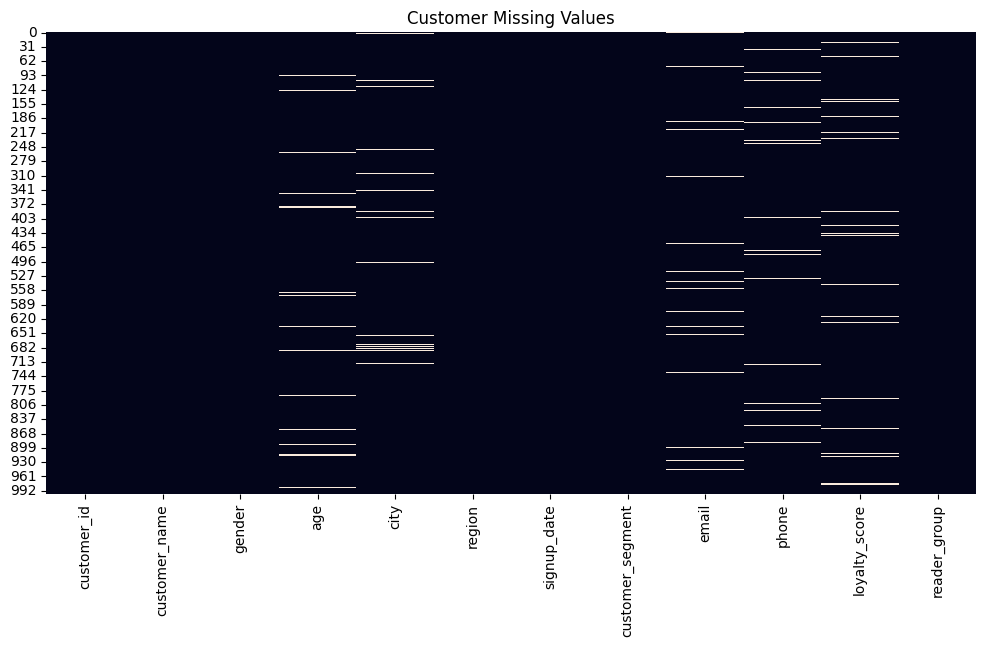

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    customers_raw.isnull(),
    cbar=False
)

plt.title("Customer Missing Values")

plt.savefig(
    "customer_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Find Invalid Values**

In [6]:
import pandas as pd

# =========================================================
# DATA QUALITY ANALYSIS MODULE
# =========================================================

# -----------------------------
# Helper Function
# -----------------------------
def show_invalid(df, condition, title):
    invalid = df[condition].copy()

    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)
    print(f"Total Invalid Records: {len(invalid)}")
    print("="*80)

    display(invalid.head(20))

    return invalid


# =========================================================
# 1. CUSTOMER DATA VALIDATION
# =========================================================

invalid_age = show_invalid(
    customers_raw,
    (customers_raw["age"] < 5) | (customers_raw["age"] > 90),
    "CUSTOMERS → INVALID AGE (5–90 RANGE VIOLATION)"
)

invalid_loyalty = show_invalid(
    customers_raw,
    (customers_raw["loyalty_score"] < 1) | (customers_raw["loyalty_score"] > 100),
    "CUSTOMERS → INVALID LOYALTY SCORE (1–100 RANGE VIOLATION)"
)


# =========================================================
# 2. PRODUCT DATA VALIDATION
# =========================================================

invalid_price = show_invalid(
    books_raw,
    books_raw["unit_price"] <= 0,
    "PRODUCTS → INVALID UNIT PRICE (<= 0)"
)


# =========================================================
# 3. SALES DATA VALIDATION
# =========================================================

invalid_quantity = show_invalid(
    sales_raw,
    sales_raw["quantity"] <= 0,
    "SALES → INVALID QUANTITY (<= 0)"
)

invalid_discount = show_invalid(
    sales_raw,
    (sales_raw["discount"] < 0) | (sales_raw["discount"] > 0.40),
    "SALES → INVALID DISCOUNT (0–40% RANGE VIOLATION)"
)


# =========================================================
# SUMMARY REPORT
# =========================================================

summary = pd.DataFrame({
    "Validation Check": [
        "Customer Age",
        "Customer Loyalty Score",
        "Product Unit Price",
        "Sales Quantity",
        "Sales Discount"
    ],
    "Invalid Count": [
        len(invalid_age),
        len(invalid_loyalty),
        len(invalid_price),
        len(invalid_quantity),
        len(invalid_discount)
    ]
})

print("\n" + "="*80)
print("DATA QUALITY SUMMARY REPORT")
print("="*80)

display(summary)


CUSTOMERS → INVALID AGE (5–90 RANGE VIOLATION)
Total Invalid Records: 6


,customer_id,customer_name,gender,age,city,region,signup_date,customer_segment,email,phone,loyalty_score,reader_group
3,C00004,Shuvo Uddin,Male,150.0,Rangamati,Chattogram,7/17/2021 6:43,Gold,rafi.sheikh@outlook.com,01423607802,80.0,Professional
43,C00044,Tasnima Roy,Male,120.0,DHAKA,Dhaka,6/3/2026 20:54,Silver,hasan.sheikh@yahoo.com,01568906441,56.0,Professional
302,C00303,Farhan Chowdhury,Male,200.0,chittagong,Chattogram,6/30/2023 15:21,Silver,sifat.mollik@outlook.com,017,49.0,Professional
374,C00375,Shuvo Uddin,Female,0.0,Munshiganj,Dhaka,2/12/2025 4:00,Gold,karim.miah@gmail.com,01975214790,70.0,Professional
707,C00708,Sakib Bhuiyan,Female,2.0,Narayanganj,Dhaka,11/30/2022 9:12,Silver,mim.chowdhury@yahoo.com,01499580232,58.0,Young
982,C00983,Shaila Mollik,Male,98.0,DHAKA,Dhaka,10/31/2021 23:04,Gold,tamim.miah@gmail.com,01364441360,77.0,Young



CUSTOMERS → INVALID LOYALTY SCORE (1–100 RANGE VIOLATION)
Total Invalid Records: 5


,customer_id,customer_name,gender,age,city,region,signup_date,customer_segment,email,phone,loyalty_score,reader_group
453,C00454,Sadia Miah,Female,7.0,DHAKA,Dhaka,5/19/2022 6:17,Platinum,shuvo.rahman@gmail.com,01548636653,180.0,Kids
457,C00458,Rumana Das,Male,48.0,chittagong,Chattogram,4/21/2024 9:00,Silver,NaN,01516026595,300.0,Professional
525,C00526,Nayeem Amin,Female,52.0,Gazipur,Dhaka,4/25/2026 6:20,Gold,nabil.karim@gmail.com,01735828388,-20.0,Professional
895,C00896,Tasnima Chowdhury,Male,53.0,Shariatpur,Dhaka,7/8/2021 6:11,Bronze,adib.khan@gmail.com,01722415416,250.0,Professional
957,C00958,Nabil Mollik,Male,26.0,COX'S BAZAR,Chattogram,2/1/2021 19:18,Silver,nabil.miah@outlook.com,01744294966,-5.0,Young



PRODUCTS → INVALID UNIT PRICE (<= 0)
Total Invalid Records: 2


...

,sales_id,supplier_id,customer_id,product_id,store_id,sales_date,quantity,unit_price,discount,total_amount,payment_method,sales_channel,reader_group,category
999,SLS001000,S00316,C00544,P00070,ST00305,1/21/2026,0.0,1104.1,0.15,938.48,Rocket,Online,Young,Academic



SALES → INVALID DISCOUNT (0–40% RANGE VIOLATION)
Total Invalid Records: 4


,sales_id,supplier_id,customer_id,product_id,store_id,sales_date,quantity,unit_price,discount,total_amount,payment_method,sales_channel,reader_group,category
749,SLS000750,S00612,C00367,P00431,ST00651,4/30/2026,3.0,258.84,-0.20,698.87,Card,In-Store,Kids,Children
1214,SLS001215,S00873,C00315,P00665,ST00781,10/8/2024,2.0,438.40,1.50,815.42,Nagad,Online,Professional,Fiction
1687,SLS001688,S00694,C00043,P00368,ST00174,5/8/2024,3.0,672.89,2.00,1816.80,bKash,Online,Young,Programming
1917,SLS001918,S00699,C00172,P00556,ST00364,4/30/2026,2.0,1403.05,0.95,2497.43,Cash,App,Professional,Business



DATA QUALITY SUMMARY REPORT


,Validation Check,Invalid Count
0,Customer Age,6
1,Customer Loyalty Score,5
2,Product Unit Price,2
3,Sales Quantity,1
4,Sales Discount,4


# **Inconsistent Text Audit**

In [7]:
import pandas as pd

# =========================================================
# DATA CONSISTENCY ANALYSIS
# =========================================================

# -----------------------------
# 1. City Variations (Customers)
# -----------------------------
print("\n" + "="*70)
print("CITY VARIATIONS (CUSTOMERS DATA)")
print("="*70)

city_variations = customers_raw["city"].value_counts().head(50)

display(city_variations)


# -----------------------------
# 2. Category Variations (Books)
# -----------------------------
print("\n" + "="*70)
print("CATEGORY VARIATIONS (BOOKS DATA)")
print("="*70)

category_variations = books_raw["category"].value_counts()

display(category_variations)


CITY VARIATIONS (CUSTOMERS DATA)


,count
city,
DHAKA,187
Lakshmipur,38
Rajbari,38
chittagong,37
COX'S BAZAR,36
Tangail,36
Gazipur,35
Shariatpur,35
Khagrachari,34



CATEGORY VARIATIONS (BOOKS DATA)


,count
category,
Fiction,146
Academic,144
Exam Prep,127
Children,107
Business,97
Programming,97
Religious,88
Self Help,61
Biography,33


# **Duplicate Audit**

In [8]:
for name, df in tables.items():

    print(
        name,
        "Duplicate Rows:",
        df.duplicated().sum()
    )

Customers Duplicate Rows: 0
Books Duplicate Rows: 0
Stores Duplicate Rows: 0
Suppliers Duplicate Rows: 0
Sales Duplicate Rows: 0


# **Outlier Visualization BEFORE Cleaning**

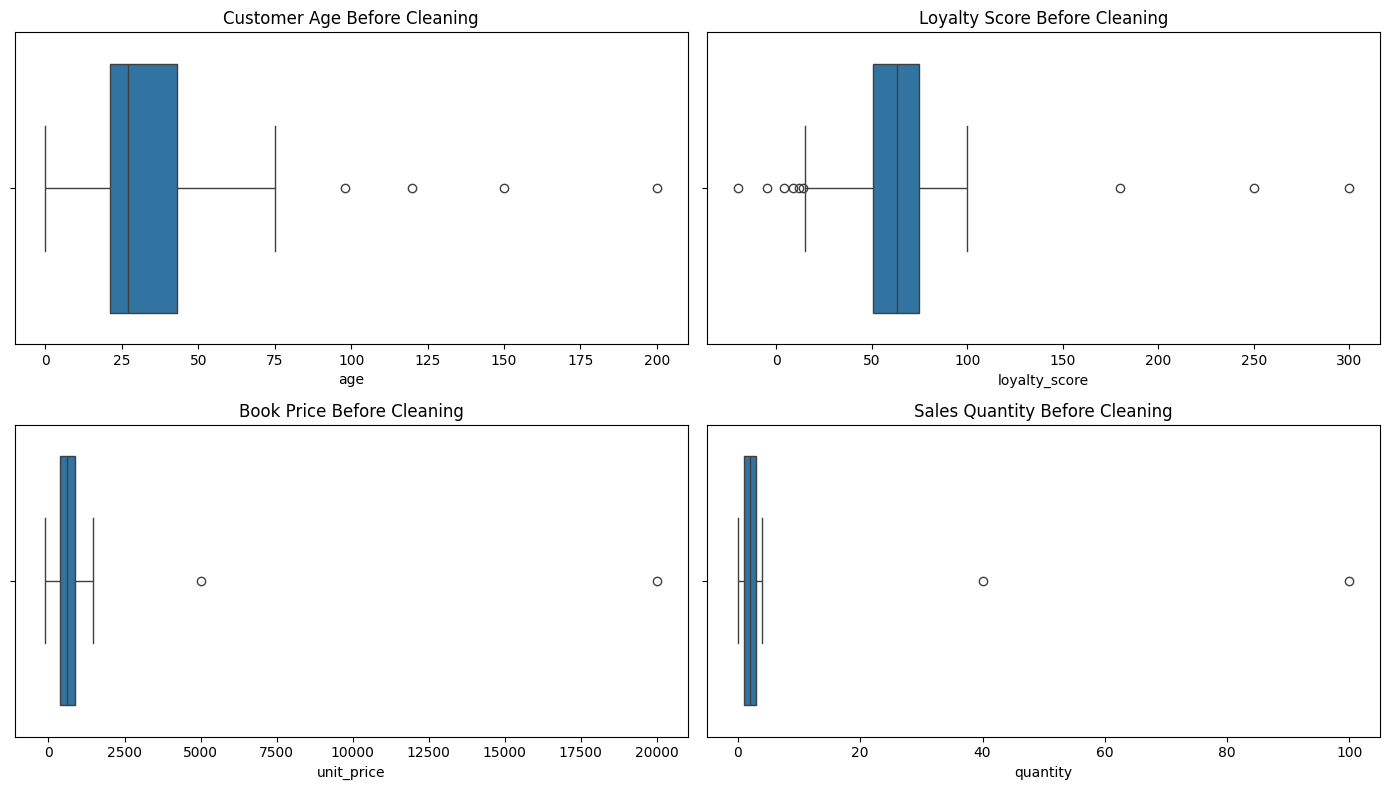

In [9]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,8)
)

sns.boxplot(
    x=customers_raw["age"],
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Customer Age Before Cleaning"
)

sns.boxplot(
    x=customers_raw["loyalty_score"],
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Loyalty Score Before Cleaning"
)

sns.boxplot(
    x=books_raw["unit_price"],
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Book Price Before Cleaning"
)

sns.boxplot(
    x=sales_raw["quantity"],
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Sales Quantity Before Cleaning"
)

plt.tight_layout()

plt.savefig(
    "outliers_before_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Data Cleaning start from here**

# **Text Cleaning Function**

In [10]:
def standardize_text(series):
   return (
       series.astype("string")
       .str.strip()
       .str.replace(r"\s+", " ", regex=True)
   )



def clean_email(series):
    s = series.astype(str).str.strip().str.lower()

    pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"
    s = s.where(s.str.match(pattern, na=False), np.nan)

    return s

def make_email(name, domain="gmail.com"):
    if pd.isna(name) or str(name).strip() == "":
        return "invalid@gmail.com"

    slug = re.sub(r"[^a-z0-9]+", ".", str(name).lower()).strip(".")

    if slug == "":
        return "invalid@gmail.com"

    return f"{slug}@{domain}"

def clean_phone(series):
   s = standardize_text(series)
   s = s.str.replace(r"\D", "", regex=True)
   s = s.where(s.str.len().between(11, 11), np.nan)
   return s

def fix_city_names(series):
    valid_cities = [
        "Dhaka", "Faridpur", "Gazipur", "Gopalganj", "Kishoreganj", "Madaripur",
        "Manikganj", "Munshiganj", "Narayanganj", "Narsingdi", "Rajbari",
        "Shariatpur", "Tangail", "Bandarban", "Brahmanbaria", "Chandpur",
        "Chittagong", "Comilla", "Cox's Bazar", "Feni", "Khagrachari",
        "Lakshmipur", "Noakhali", "Rangamati"
    ]

    mapping = {c.lower(): c for c in valid_cities}

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .fillna(series)
    )
def map_region(series):
    district_to_region = {
        "Dhaka": "Dhaka",
        "Faridpur": "Dhaka",
        "Gazipur": "Dhaka",
        "Gopalganj": "Dhaka",
        "Kishoreganj": "Dhaka",
        "Madaripur": "Dhaka",
        "Manikganj": "Dhaka",
        "Munshiganj": "Dhaka",
        "Narayanganj": "Dhaka",
        "Narsingdi": "Dhaka",
        "Rajbari": "Dhaka",
        "Shariatpur": "Dhaka",
        "Tangail": "Dhaka",
        "Bandarban": "Chattogram",
        "Brahmanbaria": "Chattogram",
        "Chandpur": "Chattogram",
        "Chittagong": "Chattogram",
        "Comilla": "Chattogram",
        "Cox's Bazar": "Chattogram",
        "Feni": "Chattogram",
        "Khagrachari": "Chattogram",
        "Lakshmipur": "Chattogram",
        "Noakhali": "Chattogram",
        "Rangamati": "Chattogram",
    }

    return series.map(district_to_region)


def make_phone(n):
    return ["0" * 11 for _ in range(n)]

# def impute_numeric_by_group(df, group_col, num_col):
#    df[num_col] = pd.to_numeric(df[num_col], errors="coerce")
#    df[num_col] = df.groupby(group_col)[num_col].transform(lambda x: x.KNNImputer)
#    df[num_col] = df[num_col].fillna(df[num_col].median())
#    return df



In [11]:
from sklearn.impute import KNNImputer

def knn_impute(df, numeric_cols, n_neighbors=5):
    temp = df.copy()
    imputer = KNNImputer(n_neighbors=n_neighbors, weights="distance")
    temp[numeric_cols] = imputer.fit_transform(temp[numeric_cols])
    return temp

In [12]:
def cap_outliers_df(df, cols, factor=1.5):
    df = df.copy()

    for col in cols:
        if col not in df.columns:
            continue

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr

        df[col] = df[col].clip(lower, upper)

    return df

# **Duplicate Removal**

In [13]:



# =========================================================
# Customers
# =========================================================
customers_clean = customers_raw.copy()

customers_clean["customer_name"] = standardize_text(customers_clean["customer_name"]).str.title()
customers_clean["gender"] = standardize_text(customers_clean["gender"]).str.title()
customers_clean["city"] = fix_city_names(customers_clean["city"])
customers_clean["region"] = map_region(customers_clean["city"])
customers_clean["email"] = clean_email(customers_clean["email"])
customers_clean["phone"] = clean_phone(customers_clean["phone"])

customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"], errors="coerce")
customers_clean["age"] = pd.to_numeric(customers_clean["age"], errors="coerce")
customers_clean["loyalty_score"] = pd.to_numeric(customers_clean["loyalty_score"], errors="coerce")

# invalid ranges → NaN
customers_clean.loc[~customers_clean["age"].between(5, 90), "age"] = np.nan
customers_clean.loc[~customers_clean["loyalty_score"].between(1, 100), "loyalty_score"] = np.nan

# KNN imputation (replaces median strategy)
customers_clean = knn_impute(customers_clean, ["age", "loyalty_score"])

customers_clean["age"] = customers_clean["age"].round().astype(int)
customers_clean["loyalty_score"] = customers_clean["loyalty_score"].round(0)

# regenerate missing emails/phones
missing_email_idx = customers_clean["email"].isna()
customers_clean.loc[missing_email_idx, "email"] = customers_clean.loc[missing_email_idx, "customer_name"].apply(make_email)

missing_phone_idx = customers_clean["phone"].isna()
customers_clean.loc[missing_phone_idx, "phone"] = make_phone(missing_phone_idx.sum())

customers_clean["reader_group"] = pd.cut(
    customers_clean["age"],
    bins=[0, 12, 29, 55, 120],
    labels=["Kids", "Young", "Professional", "Elderly"],
    include_lowest=True
).astype(str)

customers_clean["customer_segment"] = pd.cut(
    customers_clean["loyalty_score"],
    bins=[0, 40, 60, 80, 100],
    labels=["Bronze", "Silver", "Gold", "Platinum"],
    include_lowest=True
).astype(str)


# =========================================================
# Suppliers
# =========================================================
suppliers_clean = suppliers_raw.copy()

suppliers_clean["supplier_name"] = standardize_text(suppliers_clean["supplier_name"]).str.title()
suppliers_clean["country"] = standardize_text(suppliers_clean["country"]).str.title()
suppliers_clean["contact_person"] = standardize_text(suppliers_clean["contact_person"]).str.title()
suppliers_clean["phone"] = clean_phone(suppliers_clean["phone"])
suppliers_clean["email"] = clean_email(suppliers_clean["email"])
suppliers_clean["city"] = fix_city_names(suppliers_clean["city"])
suppliers_clean["region"] = map_region(suppliers_clean["city"])

suppliers_clean["rating"] = pd.to_numeric(suppliers_clean["rating"], errors="coerce")
suppliers_clean["delivery_time_days"] = pd.to_numeric(suppliers_clean["delivery_time_days"], errors="coerce")

suppliers_clean = knn_impute(suppliers_clean, ["rating", "delivery_time_days"])

suppliers_clean["rating"] = suppliers_clean["rating"].round(2)
suppliers_clean["delivery_time_days"] = suppliers_clean["delivery_time_days"].round().astype(int)

suppliers_clean["contract_start_date"] = pd.to_datetime(suppliers_clean["contract_start_date"], errors="coerce")
suppliers_clean["status"] = standardize_text(suppliers_clean["status"]).str.title().fillna("Active")


# =========================================================
# Stores
# =========================================================
stores_clean = stores_raw.copy()

stores_clean["store_name"] = standardize_text(stores_clean["store_name"]).str.title()
stores_clean["city"] = fix_city_names(stores_clean["city"])
stores_clean["region"] = map_region(stores_clean["city"])
stores_clean["store_type"] = standardize_text(stores_clean["store_type"]).str.title()
stores_clean["manager_name"] = standardize_text(stores_clean["manager_name"]).str.title()
stores_clean["opening_date"] = pd.to_datetime(stores_clean["opening_date"], errors="coerce")

for col in ["floor_area", "monthly_rent", "employee_count", "store_rating"]:
    stores_clean[col] = pd.to_numeric(stores_clean[col], errors="coerce")

stores_clean = knn_impute(
    stores_clean,
    ["floor_area", "monthly_rent", "employee_count", "store_rating"]
)

stores_clean["employee_count"] = stores_clean["employee_count"].round().astype(int)

stores_clean = cap_outliers_df(
    stores_clean,
    ["floor_area", "monthly_rent", "employee_count", "store_rating"]
)


# =========================================================
# Books
# =========================================================
books_clean = books_raw.copy()

books_clean["product_name"] = standardize_text(books_clean["product_name"]).str.title()
books_clean["category"] = standardize_text(books_clean["category"]).str.title()
books_clean["sub_category"] = standardize_text(books_clean["sub_category"]).str.title()
books_clean["author_name"] = standardize_text(books_clean["author_name"]).str.title()
books_clean["publisher_name"] = standardize_text(books_clean["publisher_name"]).str.title()
books_clean["supplier_id"] = standardize_text(books_clean["supplier_id"]).str.upper()
books_clean["format"] = standardize_text(books_clean["format"]).str.title()
books_clean["language"] = standardize_text(books_clean["language"]).str.title()
books_clean["reader_group"] = standardize_text(books_clean["reader_group"]).str.title()
books_clean["launch_date"] = pd.to_datetime(books_clean["launch_date"], errors="coerce")

for col in ["unit_price", "cost_price", "stock_quantity", "page_count", "best_seller_score"]:
    books_clean[col] = pd.to_numeric(books_clean[col], errors="coerce")

books_clean.loc[books_clean["unit_price"] <= 0, "unit_price"] = np.nan
books_clean.loc[books_clean["cost_price"] <= 0, "cost_price"] = np.nan
books_clean.loc[books_clean["stock_quantity"] < 0, "stock_quantity"] = np.nan
books_clean.loc[books_clean["page_count"] <= 0, "page_count"] = np.nan

books_clean = knn_impute(
    books_clean,
    ["unit_price", "cost_price", "stock_quantity", "page_count", "best_seller_score"]
)

books_clean["stock_quantity"] = books_clean["stock_quantity"].round().astype(int)
books_clean["page_count"] = books_clean["page_count"].round().astype(int)

books_clean = cap_outliers_df(
    books_clean,
    ["unit_price", "cost_price", "stock_quantity", "page_count", "best_seller_score"]
)


# =========================================================
# Sales
# =========================================================
sales_clean = sales_raw.copy()

sales_clean["sales_date"] = pd.to_datetime(sales_clean["sales_date"], errors="coerce")
sales_clean["quantity"] = pd.to_numeric(sales_clean["quantity"], errors="coerce")
sales_clean["unit_price"] = pd.to_numeric(sales_clean["unit_price"], errors="coerce")
sales_clean["discount"] = pd.to_numeric(sales_clean["discount"], errors="coerce")
sales_clean["total_amount"] = pd.to_numeric(sales_clean["total_amount"], errors="coerce")

sales_clean["payment_method"] = standardize_text(sales_clean["payment_method"]).str.title()
sales_clean["sales_channel"] = standardize_text(sales_clean["sales_channel"]).str.title()
sales_clean["reader_group"] = standardize_text(sales_clean["reader_group"]).str.title()
sales_clean["category"] = standardize_text(sales_clean["category"]).str.title()

sales_clean.loc[~sales_clean["quantity"].between(1, 20), "quantity"] = np.nan
sales_clean.loc[~sales_clean["discount"].between(0, 0.40), "discount"] = np.nan
sales_clean.loc[sales_clean["unit_price"] <= 0, "unit_price"] = np.nan

sales_clean = knn_impute(
    sales_clean,
    ["quantity", "unit_price", "discount", "total_amount"]
)

sales_clean["quantity"] = sales_clean["quantity"].round().astype(int)

sales_clean = cap_outliers_df(
    sales_clean,
    ["quantity", "unit_price", "discount", "total_amount"]
)

sales_clean["discount"] = sales_clean["discount"].clip(0, 0.40)

sales_clean["sales_date"] = sales_clean["sales_date"].fillna(sales_clean["sales_date"].median())

sales_clean["total_amount"] = np.round(
    sales_clean["quantity"] * sales_clean["unit_price"] * (1 - sales_clean["discount"]),
    2
)

In [14]:
print("SUPPLIER ID EXISTS:", "supplier_id" in suppliers_clean.columns)
print("ALL COLUMNS:", suppliers_clean.columns.tolist())

SUPPLIER ID EXISTS: True
ALL COLUMNS: ['supplier_id', 'supplier_name', 'country', 'contact_person', 'phone', 'email', 'product_category', 'rating', 'contract_start_date', 'delivery_time_days', 'city', 'status', 'region']


In [15]:
print(type(suppliers_clean.columns))
print(suppliers_clean.columns)

<class 'pandas.core.indexes.base.Index'>
Index(['supplier_id', 'supplier_name', 'country', 'contact_person', 'phone',
       'email', 'product_category', 'rating', 'contract_start_date',
       'delivery_time_days', 'city', 'status', 'region'],
      dtype='object')


In [16]:
print(suppliers_clean.columns.duplicated().sum())

0


In [17]:
print(id(suppliers_clean))
print(suppliers_clean.shape)
print("supplier_id" in suppliers_clean.columns)

136258884166688
(1000, 13)
True


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# =========================================================
# 1. REMOVE DUPLICATES (FINAL CLEAN TABLES)
# =========================================================
customers_clean = customers_clean.drop_duplicates(subset=["customer_id"]).reset_index(drop=True)
books_clean = books_clean.drop_duplicates(subset=["product_id"]).reset_index(drop=True)
suppliers_clean = suppliers_clean.drop_duplicates(subset=["supplier_id"]).reset_index(drop=True)
stores_clean = stores_clean.drop_duplicates(subset=["store_id"]).reset_index(drop=True)
sales_clean = sales_clean.drop_duplicates(subset=["sales_id"]).reset_index(drop=True)

# =========================================================
# 2. EXPORT CLEAN TABLES (POWER BI READY LAYER)
# =========================================================
customers_clean.to_csv("customers_clean.csv", index=False)
books_clean.to_csv("books_clean.csv", index=False)
suppliers_clean.to_csv("suppliers_clean.csv", index=False)
stores_clean.to_csv("stores_clean.csv", index=False)
sales_clean.to_csv("sales_clean.csv", index=False)

print("Clean tables exported for Power BI")


Clean tables exported for Power BI


In [19]:


# =========================================================
# 3. CREATE ANALYTICS / ML MERGED DATASET
# =========================================================
# =========================================================
# =========================================================
# FULL 5-TABLE MERGE (FACT + 4 DIMENSIONS)
# =========================================================

# =========================================================
# FULL 5-TABLE MERGE — CLEAN COLUMN SELECTION
# =========================================================

final_df = (
    sales_clean[[
        "sales_id", "customer_id", "product_id", "store_id",
        "sales_date", "quantity", "unit_price", "discount",
        "total_amount", "payment_method", "sales_channel",
    ]]

    # -------------------------
    # CUSTOMER DIMENSION
    # -------------------------
    .merge(
        customers_clean[[
            "customer_id", "customer_name", "gender", "age",
            "city", "region", "signup_date", "customer_segment",
            "loyalty_score", "reader_group",
        ]].rename(columns={
            "city"         : "customer_city",
            "region"       : "customer_region",
            "reader_group" : "customer_reader_group",
        }),
        on="customer_id",
        how="left"
    )

    # -------------------------
    # PRODUCT / BOOK DIMENSION
    # -------------------------
    .merge(
        books_clean[[
            "product_id", "product_name", "category", "sub_category",
            "author_name", "publisher_name", "format", "language",
            "unit_price", "cost_price", "stock_quantity",
            "page_count", "best_seller_score", "reader_group",
            "launch_date", "supplier_id",
        ]].rename(columns={
            "category"    : "book_category",
            "unit_price"  : "book_unit_price",
            "reader_group": "book_reader_group",
            "supplier_id" : "book_supplier_id",
        }),
        on="product_id",
        how="left"
    )

    # -------------------------
    # STORE DIMENSION
    # -------------------------
    .merge(
        stores_clean[[
            "store_id", "store_name", "city", "region",
            "store_type", "manager_name", "floor_area",
            "monthly_rent", "employee_count", "store_rating",
        ]].rename(columns={
            "city"   : "store_city",
            "region" : "store_region",
        }),
        on="store_id",
        how="left"
    )

    # -------------------------
    # SUPPLIER DIMENSION
    # -------------------------
    .merge(
        suppliers_clean[[
            "supplier_id", "supplier_name", "country",
            "rating", "delivery_time_days", "status",
        ]].rename(columns={
            "supplier_id" : "book_supplier_id",
            "rating"      : "supplier_rating",
        }),
        on="book_supplier_id",
        how="left"
    )
)

print(f"Shape: {final_df.shape}")
print(f"Columns:\n{final_df.columns.tolist()}")



# =========================================================
# 4. FEATURE ENGINEERING (CLUSTERING FEATURES)
# =========================================================
final_df["profit"] = (final_df["unit_price"] - final_df["cost_price"]) * final_df["quantity"]
final_df["discount_pct"] = final_df["discount"] * 100
final_df["order_month"] = final_df["sales_date"].dt.to_period("M").astype(str)
final_df["customer_tenure_days"] = (final_df["sales_date"] - final_df["signup_date"]).dt.days
final_df["book_age_days"] = (final_df["sales_date"] - final_df["launch_date"]).dt.days
final_df["basket_value"] = final_df["total_amount"]

# =========================================================
# 5. CLUSTERING DATA PREPARATION
#    (IMPORTANT: NUMERIC ONLY)
# =========================================================
cluster_features = final_df.select_dtypes(include=[np.number]).copy()

# drop rows with missing values AFTER merge
cluster_features = cluster_features.dropna()

# scaling (critical for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("Clustering matrix shape:", X_scaled.shape)






Shape: (2000, 49)
Columns:
['sales_id', 'customer_id', 'product_id', 'store_id', 'sales_date', 'quantity', 'unit_price', 'discount', 'total_amount', 'payment_method', 'sales_channel', 'customer_name', 'gender', 'age', 'customer_city', 'customer_region', 'signup_date', 'customer_segment', 'loyalty_score', 'customer_reader_group', 'product_name', 'book_category', 'sub_category', 'author_name', 'publisher_name', 'format', 'language', 'book_unit_price', 'cost_price', 'stock_quantity', 'page_count', 'best_seller_score', 'book_reader_group', 'launch_date', 'book_supplier_id', 'store_name', 'store_city', 'store_region', 'store_type', 'manager_name', 'floor_area', 'monthly_rent', 'employee_count', 'store_rating', 'supplier_name', 'country', 'supplier_rating', 'delivery_time_days', 'status']
Clustering matrix shape: (2000, 22)


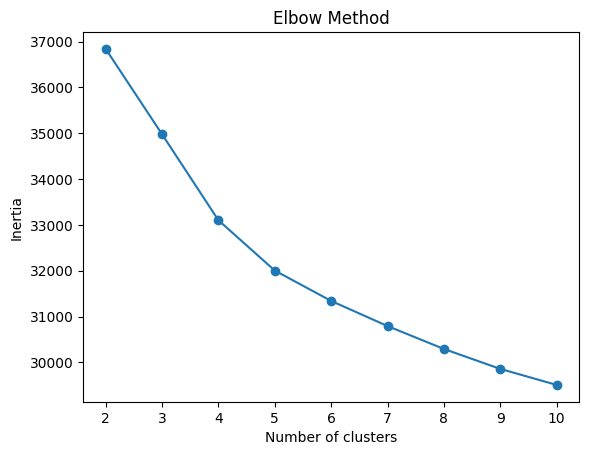

In [20]:
# =========================================================
# ELBOW METHOD (300 DPI SAVE)
# =========================================================
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()


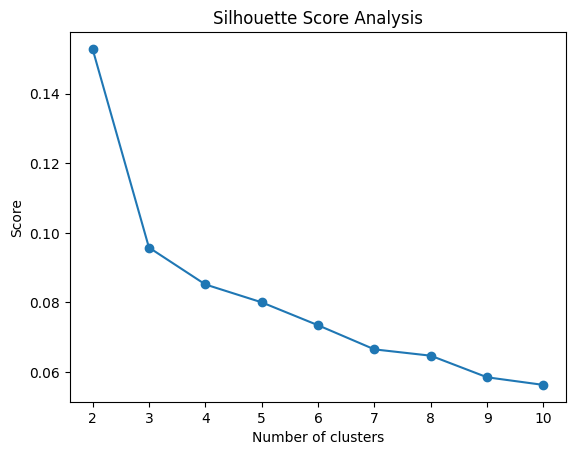

In [21]:
# =========================================================
# SILHOUETTE SCORE (300 DPI SAVE)
# =========================================================
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure()
plt.plot(range(2, 11), sil_scores, marker="o")
plt.title("Silhouette Score Analysis")
plt.xlabel("Number of clusters")
plt.ylabel("Score")

plt.savefig("silhouette_score.png", dpi=300, bbox_inches="tight")
plt.show()

# **K-Means Clustering**

Silhouette Score (k=4): 0.0815
Cluster sizes:
cluster
0    507
1    450
2    475
3    381
Name: count, dtype: int64

=== CLUSTER PROFILE ===
cluster                   0         1        2             3
count                   507       450      475           381
avg_age               24.09     23.68    25.54         47.97
avg_loyalty           62.78     64.28    62.54         62.91
avg_spend            834.15   2239.26   931.48        829.43
avg_quantity            1.7      3.16     1.93          1.47
avg_discount           0.05      0.06     0.12          0.07
avg_page_count       433.79    424.03   438.25        397.76
avg_bestseller          0.7      0.65     0.71          0.66
top_reader_group      Young     Young    Young  Professional
top_category       Children  Academic  Fiction      Academic
top_format        Paperback     Ebook    Ebook         Ebook
top_channel        In-Store  In-Store   Online        Online
top_segment            Gold      Gold     Gold        Silver


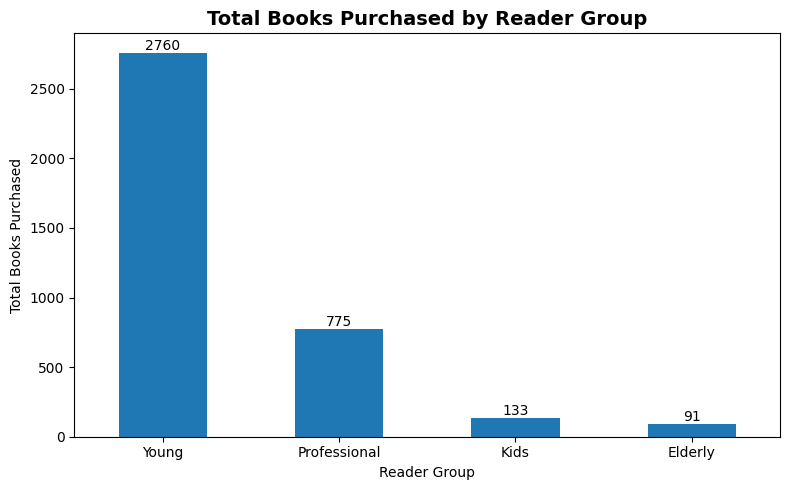

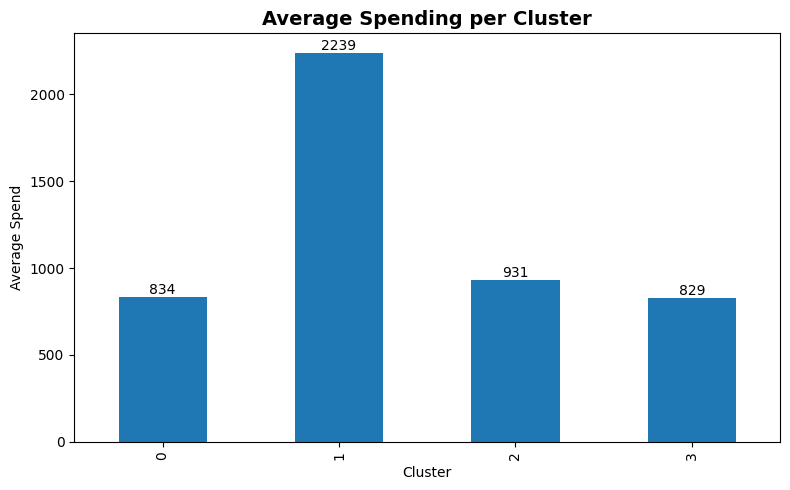

<Figure size 1000x600 with 0 Axes>

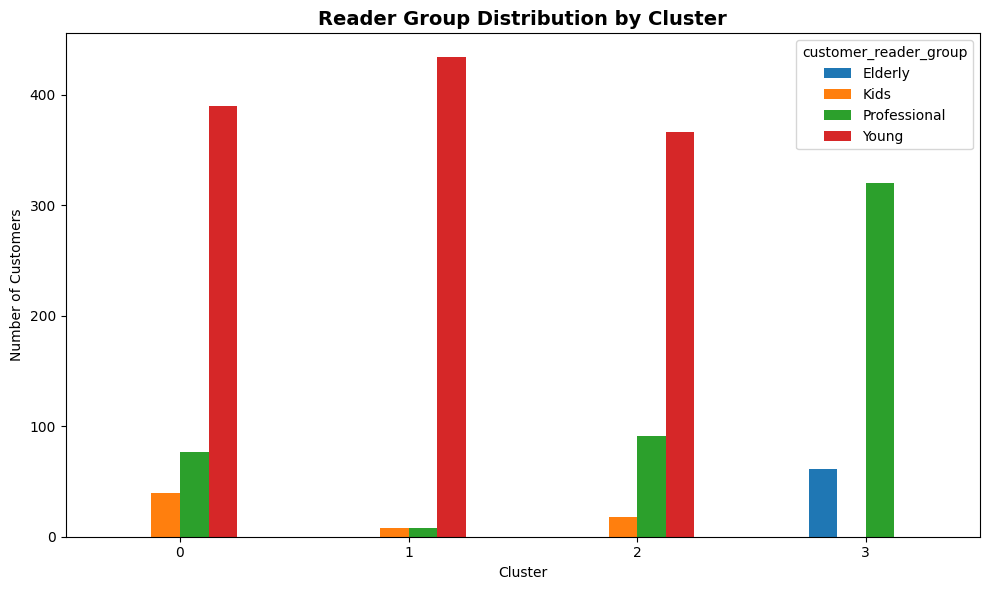

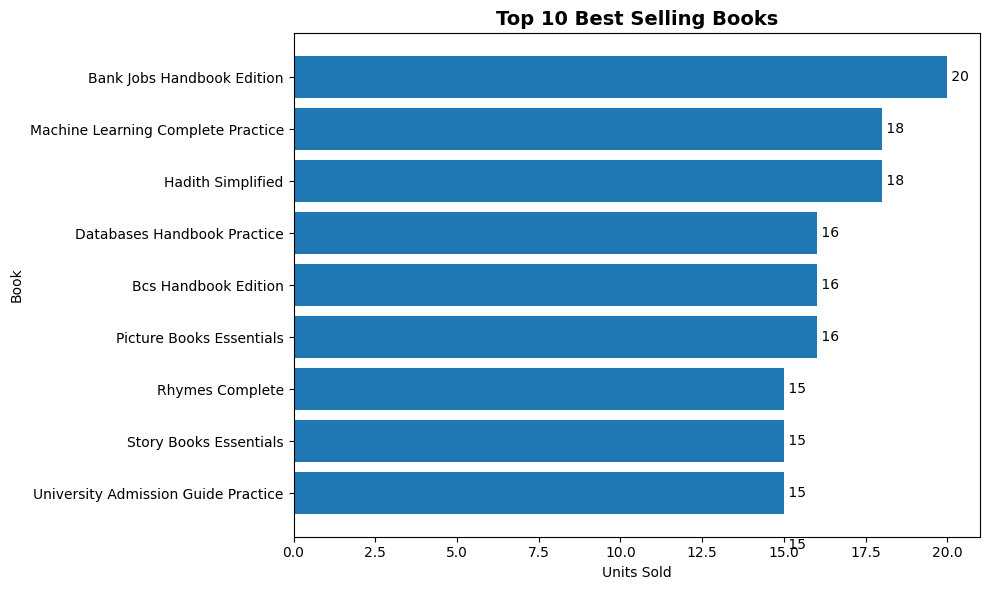

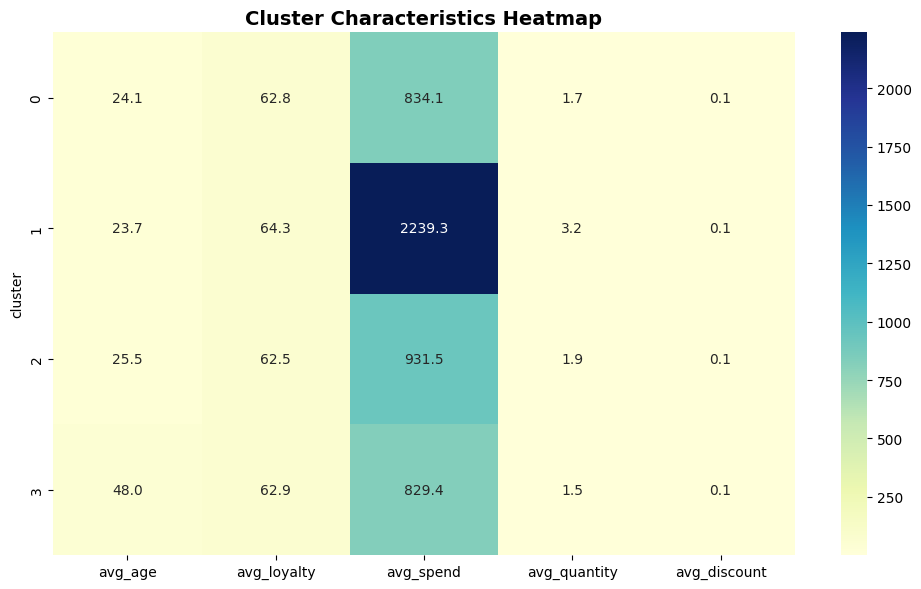

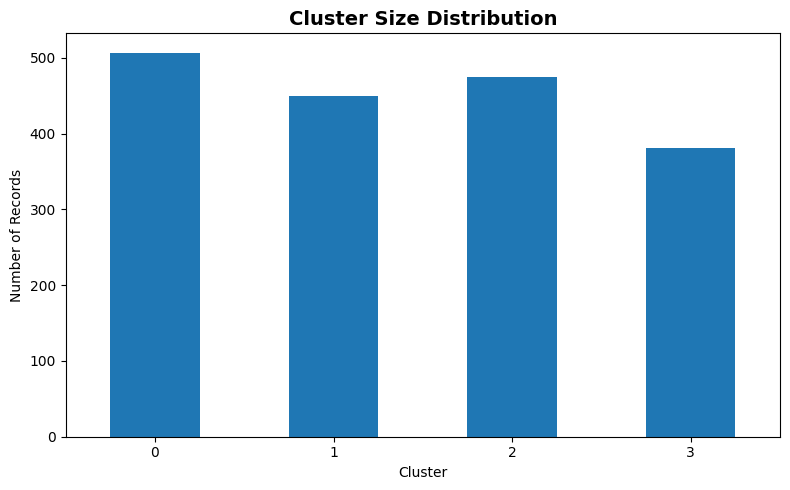

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================================================
# STEP 1: FEATURE SELECTION FOR CLUSTERING
# =========================================================
cluster_cols = [
    "age", "loyalty_score", "total_amount", "quantity",
    "discount", "page_count", "best_seller_score",
    "customer_reader_group", "book_category", "format",
    "payment_method", "sales_channel", "store_type", "customer_segment"
]

cluster_df = final_df[cluster_cols].copy().dropna()

# =========================================================
# STEP 2: ENCODE CATEGORICALS
# =========================================================
cat_cols = [
    "customer_reader_group", "book_category", "format",
    "payment_method", "sales_channel", "store_type", "customer_segment"
]

le = LabelEncoder()
for col in cat_cols:
    cluster_df[col + "_enc"] = le.fit_transform(cluster_df[col].astype(str))

feature_cols = [
    "age", "loyalty_score", "total_amount", "quantity",
    "discount", "page_count", "best_seller_score",
    "customer_reader_group_enc", "book_category_enc", "format_enc",
    "payment_method_enc", "sales_channel_enc",
    "store_type_enc", "customer_segment_enc"
]

X = cluster_df[feature_cols]

# =========================================================
# STEP 3: SCALE
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# STEP 4: FIT K-MEANS WITH k=4
# =========================================================
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = km.fit_predict(X_scaled)

# Map to meaningful labels after profiling
cluster_labels = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2", 3: "Cluster 3"}
cluster_df["cluster_label"] = cluster_df["cluster"].map(cluster_labels)

print(f"Silhouette Score (k=4): {silhouette_score(X_scaled, cluster_df['cluster']):.4f}")
print(f"Cluster sizes:\n{cluster_df['cluster'].value_counts().sort_index()}")

# =========================================================
# STEP 5: CLUSTER PROFILE SUMMARY
# =========================================================
cluster_profile = (
    cluster_df.groupby("cluster")
    .agg(
        count            = ("age",               "count"),
        avg_age          = ("age",               "mean"),
        avg_loyalty      = ("loyalty_score",     "mean"),
        avg_spend        = ("total_amount",      "mean"),
        avg_quantity     = ("quantity",          "mean"),
        avg_discount     = ("discount",          "mean"),
        avg_page_count   = ("page_count",        "mean"),
        avg_bestseller   = ("best_seller_score", "mean"),
        top_reader_group = ("customer_reader_group", lambda x: x.value_counts().index[0]),
        top_category     = ("book_category",     lambda x: x.value_counts().index[0]),
        top_format       = ("format",            lambda x: x.value_counts().index[0]),
        top_channel      = ("sales_channel",     lambda x: x.value_counts().index[0]),
        top_segment      = ("customer_segment",  lambda x: x.value_counts().index[0]),
    )
    .round(2)
)
print("\n=== CLUSTER PROFILE ===")
print(cluster_profile.T)

# # =========================================================
# # STEP 6: WHICH READER GROUP READS MOST?
# # =========================================================

plt.figure(figsize=(8,5))

ax = reader_summary["total_books"].plot(
    kind="bar",
    rot=0
)

plt.title("Total Books Purchased by Reader Group", fontsize=14, fontweight="bold")
plt.xlabel("Reader Group")
plt.ylabel("Total Books Purchased")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("total_books_by_reader_group.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================

plt.figure(figsize=(8,5))

ax = cluster_profile["avg_spend"].plot(
    kind="bar"
)

plt.title("Average Spending per Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Average Spend")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("avg_spend_per_cluster.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================

plt.figure(figsize=(10,6))

reader_cluster = (
    cluster_df.groupby(
        ["cluster", "customer_reader_group"]
    )
    .size()
    .unstack(fill_value=0)
)

reader_cluster.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Reader Group Distribution by Cluster",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("reader_group_distribution_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# STEP 7: TOP 10 BEST SELLING BOOKS
# =========================================================

plt.figure(figsize=(10,6))

ax = plt.barh(
    top10_books["product_name"].str[:40],
    top10_books["total_units_sold"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Best Selling Books",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Units Sold")
plt.ylabel("Book")

for i, value in enumerate(top10_books["total_units_sold"]):
    plt.text(
        value,
        i,
        f" {value}",
        va="center"
    )

plt.tight_layout()

plt.savefig("top_10_best_selling_books.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# STEP 8: PLOTS
# =========================================================

plt.figure(figsize=(10,6))

heatmap_data = cluster_profile[
    [
        "avg_age",
        "avg_loyalty",
        "avg_spend",
        "avg_quantity",
        "avg_discount"
    ]
]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Cluster Characteristics Heatmap",
          fontsize=14,
          fontweight="bold")

plt.tight_layout()

plt.savefig("cluster_characteristics_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================

plt.figure(figsize=(8,5))

cluster_df["cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cluster Size Distribution",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Cluster")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("cluster_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

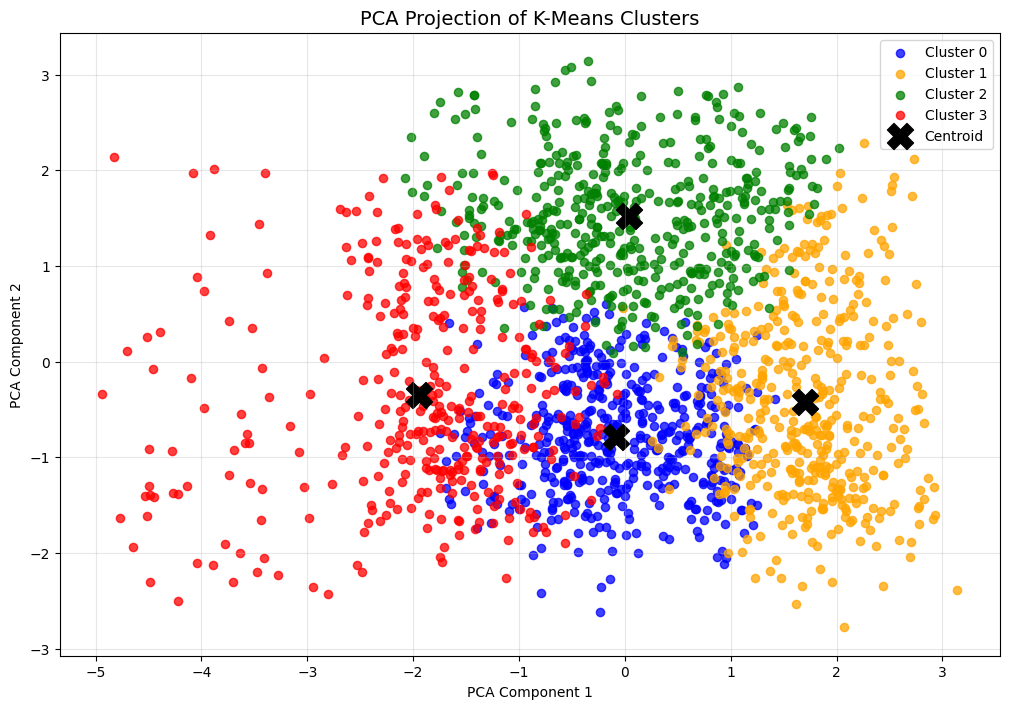

In [37]:
# =========================================================
# K-MEANS CLUSTER VISUALIZATION (PCA 2D)
# =========================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce dimensions to 2D
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

# Transform cluster centers into same PCA space
centers_pca = pca.transform(km.cluster_centers_)

plt.figure(figsize=(10,7))

colors = ["blue", "orange", "green", "red"]

for i in range(4):
    cluster_points = X_pca[cluster_df["cluster"] == i]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=35,
        color=colors[i],
        label=f"Cluster {i}",
        alpha=0.75
    )

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="black",
    s=350,
    marker="X",
    label="Centroid"
)

plt.title("PCA Projection of K-Means Clusters", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()

# ✅ SAVE HIGH-RES FIGURE (300 DPI)
plt.savefig("kmeans_pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

# **K-Means Clustering**

In [38]:
# fig, axes = plt.subplots(
#     2,
#     2,
#     figsize=(14,8)
# )

# sns.boxplot(
#     x=customers_clean["age"],
#     ax=axes[0,0]
# )

# sns.boxplot(
#     x=customers_clean["loyalty_score"],
#     ax=axes[0,1]
# )

# sns.boxplot(
#     x=books_clean["unit_price"],
#     ax=axes[1,0]
# )

# sns.boxplot(
#     x=sales_clean["quantity"],
#     ax=axes[1,1]
# )

# plt.tight_layout()

# plt.savefig(
#     "outliers_after_cleaning.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

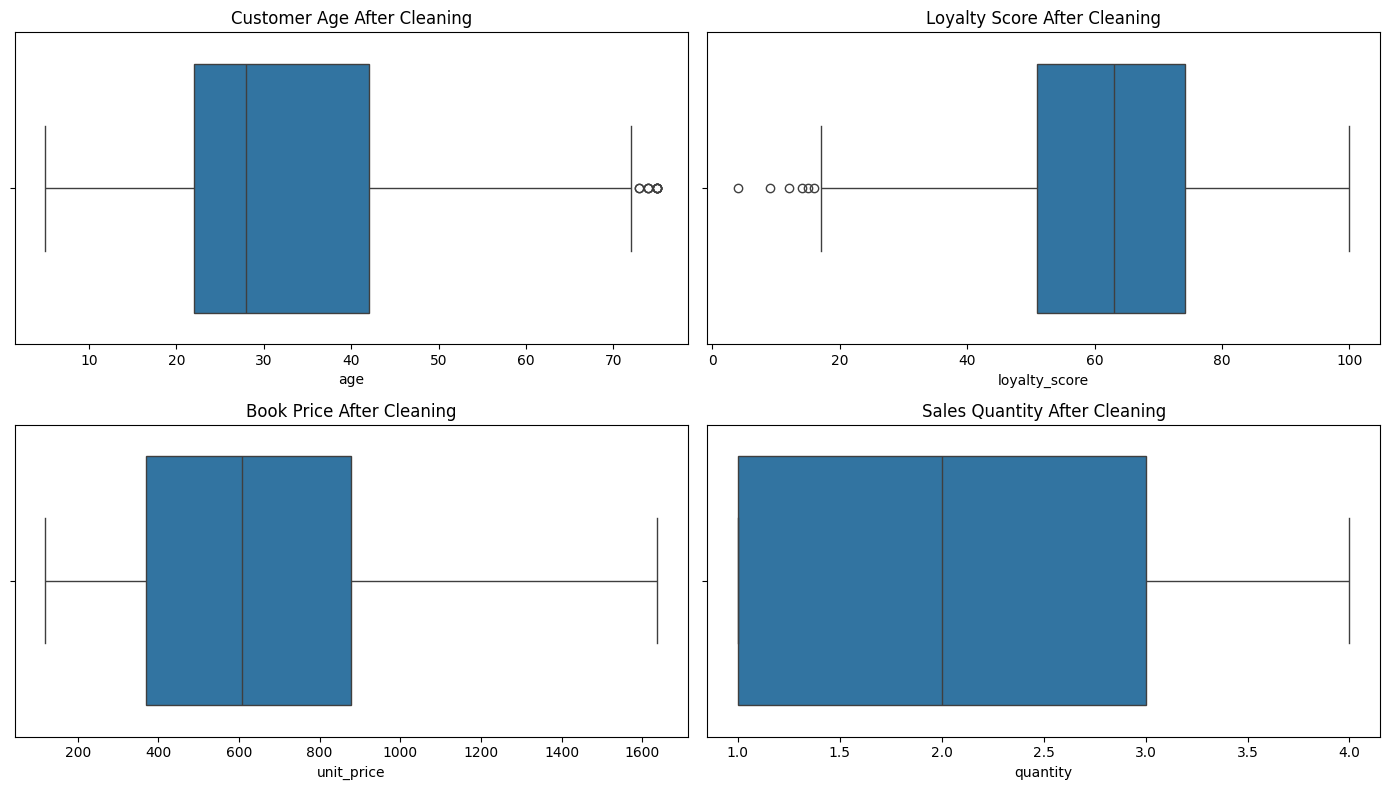

In [39]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,8)
)

sns.boxplot(
    x=customers_clean["age"],
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Customer Age After Cleaning"
)

sns.boxplot(
    x=customers_clean["loyalty_score"],
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Loyalty Score After Cleaning"
)

sns.boxplot(
    x=books_clean["unit_price"],
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Book Price After Cleaning"
)

sns.boxplot(
    x=sales_clean["quantity"],
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Sales Quantity After Cleaning"
)

plt.tight_layout()

plt.savefig(
    "outliers_after_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()